In [2]:
!pip install librosa

  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached audioread-3.1.0-py3-none-any.whl.metadata (9.0 kB)
  Using cached soundfile-0.13.1-py2.py3-none-win_amd64.whl.metadata (16 kB)
  Using cached pooch-1.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached soxr-1.0.0-cp312-abi3-win_amd64.whl.metadata (5.6 kB)
  Using cached standard_aifc-3.13.0-py3-none-any.whl.metadata (969 bytes)
  Using cached standard_sunau-3.13.0-py3-none-any.whl.metadata (914 bytes)
  Using cached standard_chunk-3.13.0-py3-none-any.whl.metadata (860 bytes)
  Using cached audioop_lts-0.2.2-cp313-abi3-win_amd64.whl.metadata (2.0 kB)
Using cached librosa-0.11.0-py3-none-any.whl (260 kB)
Using cached audioread-3.1.0-py3-none-any.whl (23 kB)
Using cached pooch-1.9.0-py3-none-any.whl (67 kB)
Using cached soundfile-0.13.1-py2.py3-none-win_amd64.whl (1.0 MB)
Using cached soxr-1.0.0-cp312-abi3-win_amd64.whl (172 kB)
Using cached standard_aifc-3.13.0-py3-none-any.whl (10 kB)
Using cached audioop_l

In [3]:
import os
import librosa
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import wavfile
import warnings
warnings.filterwarnings("ignore")

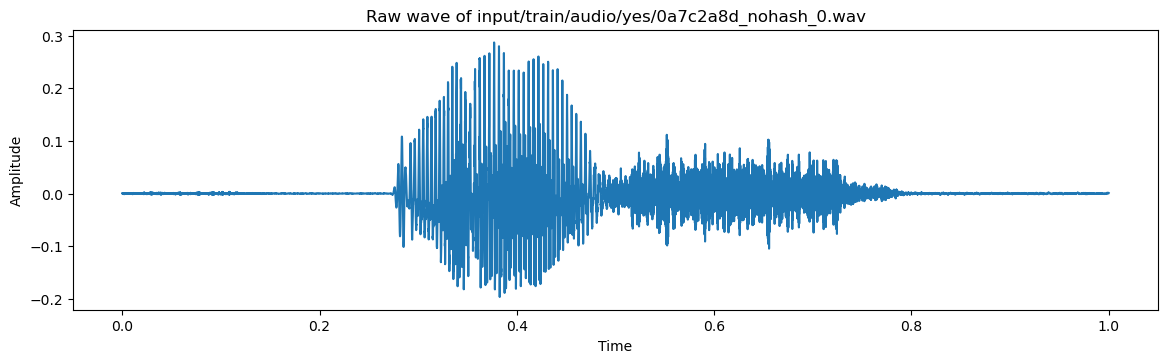

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import librosa

train_audio_path = 'Downloads/tensorflow-speech-recognition-challenge/train/train/audio/'

samples, sample_rate = librosa.load(
    train_audio_path + 'yes/0a7c2a8d_nohash_0.wav',
    sr=16000
)

fig = plt.figure(figsize=(14, 8))
ax1 = fig.add_subplot(211)

ax1.set_title('Raw wave of input/train/audio/yes/0a7c2a8d_nohash_0.wav')
ax1.set_xlabel('Time')
ax1.set_ylabel('Amplitude')

# Correct time axis
time_axis = np.linspace(0, len(samples) / sample_rate, len(samples))
ax1.plot(time_axis, samples)

plt.show()

In [9]:
import IPython.display as ipd

ipd.Audio(samples, rate=sample_rate)

In [10]:
print(sample_rate)

16000


In [12]:
samples = librosa.resample(y=samples, orig_sr=sample_rate, target_sr=8000)

In [13]:
labels=os.listdir(train_audio_path)

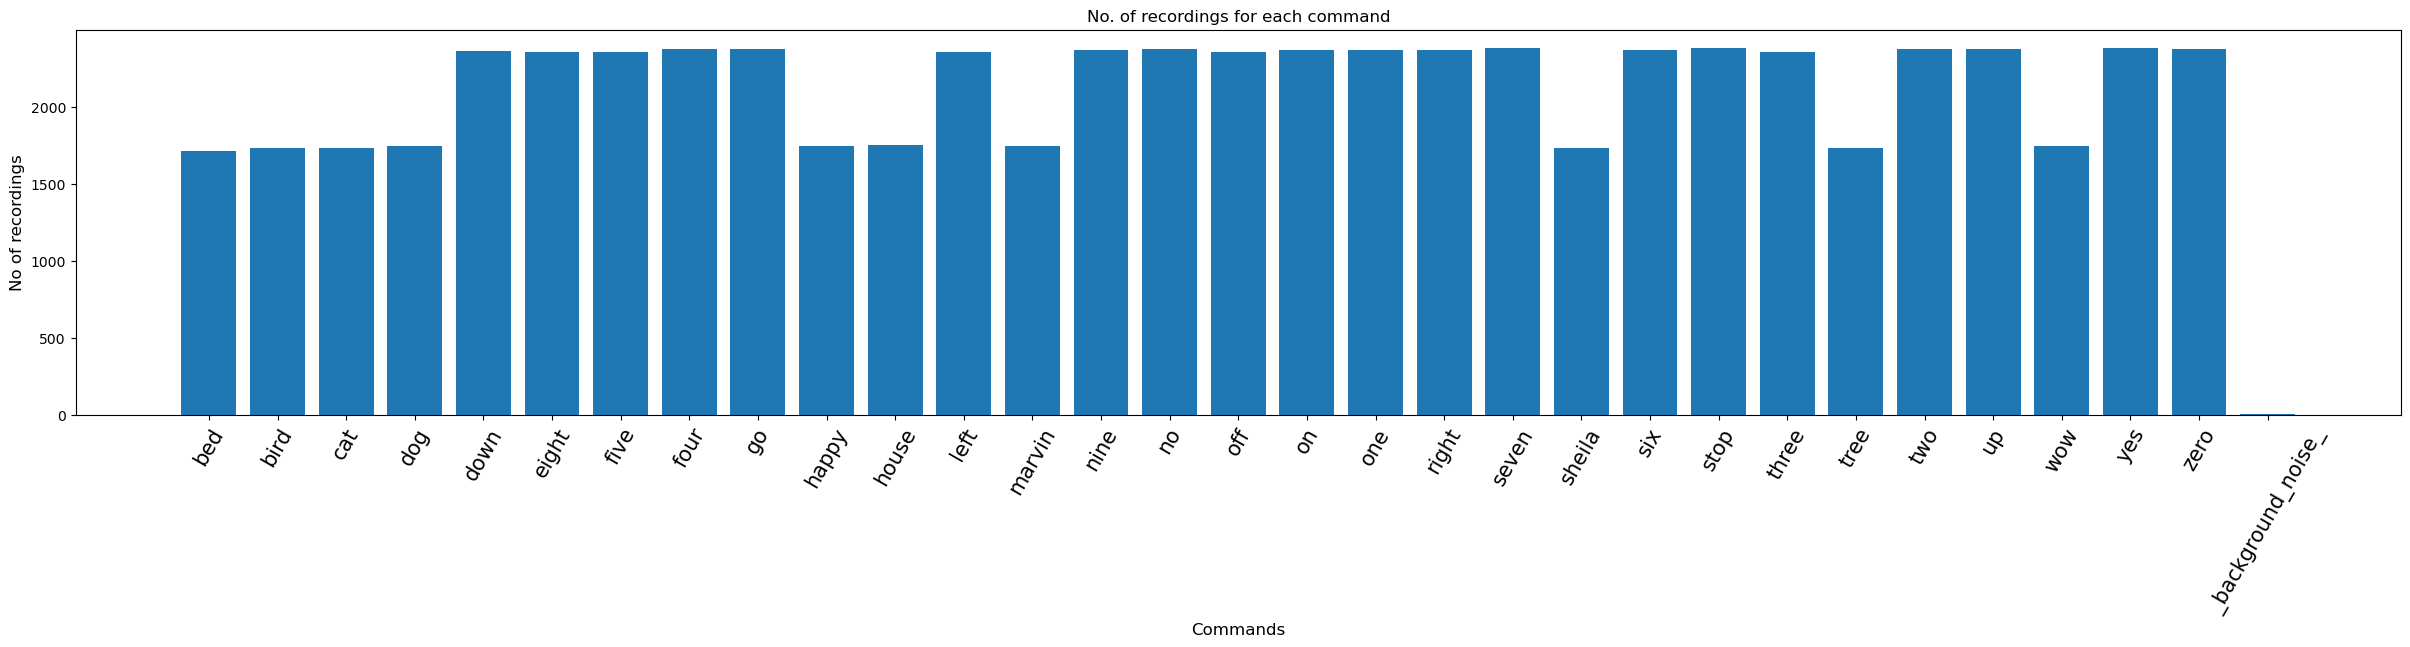

In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt

no_of_recordings = []

for label in labels:
    waves = [
        f for f in os.listdir(train_audio_path + '/' + label)
        if f.endswith('.wav')
    ]
    no_of_recordings.append(len(waves))

# Plot
plt.figure(figsize=(30, 5))
index = np.arange(len(labels))

plt.bar(index, no_of_recordings)

plt.xlabel('Commands', fontsize=12)
plt.ylabel('No of recordings', fontsize=12)

plt.xticks(index, labels, fontsize=15, rotation=60)
plt.title('No. of recordings for each command')

plt.show()

In [16]:
labels=["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"]

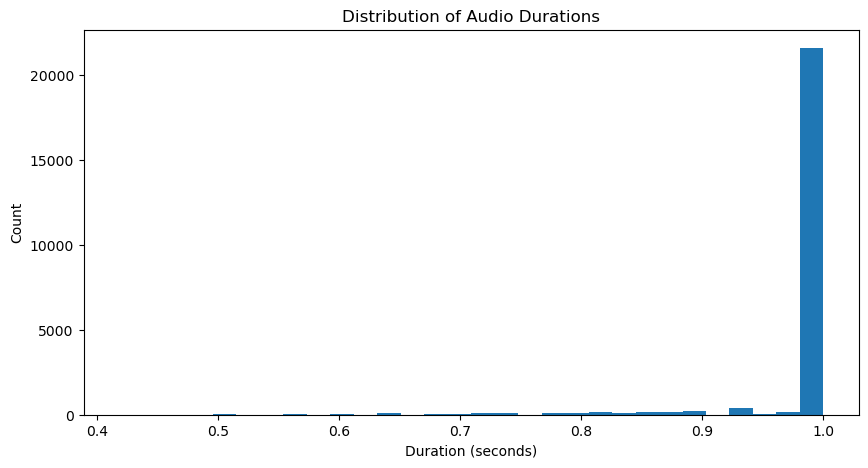

In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

duration_of_recordings = []

for label in labels:
    waves = [
        f for f in os.listdir(train_audio_path + '/' + label)
        if f.endswith('.wav')
    ]
    
    for wav in waves:
        sample_rate, samples = wavfile.read(
            train_audio_path + '/' + label + '/' + wav
        )
        
        duration = len(samples) / sample_rate
        duration_of_recordings.append(float(duration))

# Plot histogram
plt.figure(figsize=(10, 5))
plt.hist(np.array(duration_of_recordings), bins=30)

plt.xlabel('Duration (seconds)')
plt.ylabel('Count')
plt.title('Distribution of Audio Durations')

plt.show()

In [19]:
import os
import librosa

train_audio_path = 'Downloads/tensorflow-speech-recognition-challenge/train/train/audio/'

all_wave = []
all_label = []

for label in labels:
    print(label)
    
    waves = [
        f for f in os.listdir(train_audio_path + '/' + label)
        if f.endswith('.wav')
    ]
    
    for wav in waves:
        samples, sample_rate = librosa.load(
            train_audio_path + '/' + label + '/' + wav,
            sr=16000
        )
        
        # Resample to 8000 Hz (new librosa syntax)
        samples = librosa.resample(
            y=samples,
            orig_sr=sample_rate,
            target_sr=8000
        )
        
        # Keep only 1-second audio (8000 samples)
        if len(samples) == 8000:
            all_wave.append(samples)
            all_label.append(label)

yes
no
up
down
left
right
on
off
stop
go


In [20]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y=le.fit_transform(all_label)
classes= list(le.classes_)

In [22]:
from tensorflow.keras import utils

In [23]:
y=utils.to_categorical(y, num_classes=len(labels))

In [24]:
all_wave = np.array(all_wave).reshape(-1,8000,1)

In [26]:
from sklearn.model_selection import train_test_split
x_tr, x_val, y_tr, y_val = train_test_split(np.array(all_wave),np.
array(y),stratify=y,test_size = 0.2,random_state=777,shuffle=True)

In [27]:
from tensorflow import keras as keras

In [28]:
#Deep learning
import tensorflow.keras as keras
#from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv1D
from tensorflow.keras import Input, layers
from tensorflow.keras import backend as K

In [29]:
K.clear_session()

In [31]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Input

inputs = Input(shape=(8000, 1))

# First Conv1D layer
conv = layers.Conv1D(filters=8, kernel_size=13, padding='valid', activation='relu', strides=1)(inputs)
conv = layers.MaxPooling1D(pool_size=3)(conv)
conv = layers.Dropout(0.3)(conv)

# Second Conv1D layer
conv = layers.Conv1D(filters=16, kernel_size=11, padding='valid', activation='relu', strides=1)(conv)
conv = layers.MaxPooling1D(pool_size=3)(conv)
conv = layers.Dropout(0.3)(conv)

# Third Conv1D layer
conv = layers.Conv1D(filters=32, kernel_size=9, padding='valid', activation='relu', strides=1)(conv)
conv = layers.MaxPooling1D(pool_size=3)(conv)
conv = layers.Dropout(0.3)(conv)

# Fourth Conv1D layer
conv = layers.Conv1D(filters=64, kernel_size=7, padding='valid', activation='relu', strides=1)(conv)
conv = layers.MaxPooling1D(pool_size=3)(conv)
conv = layers.Dropout(0.3)(conv)

# Flatten
conv = layers.Flatten()(conv)

# Dense layers
conv = layers.Dense(256, activation='relu')(conv)
conv = layers.Dropout(0.3)(conv)

conv = layers.Dense(128, activation='relu')(conv)
conv = layers.Dropout(0.3)(conv)

# Output layer
outputs = layers.Dense(len(labels), activation='softmax')(conv)

# Model
model = keras.Model(inputs=inputs, outputs=outputs)

# Summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 8000, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 7988, 8)        │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2662, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2662, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2652, 16)       │         1,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 884, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 884, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 876, 32)        │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 292, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 292, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 286, 64)        │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 95, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 95, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6080)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,556,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,611,498 (6.15 MB)

 Trainable params: 1,611,498 (6.15 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [34]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [37]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

es = EarlyStopping(
    monitor='val_loss',
    mode='min',
    verbose=1,
    patience=10,
    min_delta=0.0001
)

mc = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    mode='max'
)

In [38]:
history=model.fit(x_tr, y_tr ,epochs=10, callbacks=[es,mc], batch_size=32,
validation_data=(x_val,y_val))

Epoch 1/10
533/533 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.1486 - loss: 2.2284
Epoch 1: val_accuracy improved from None to 0.24912, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
533/533 ━━━━━━━━━━━━━━━━━━━━ 206s 344ms/step - accuracy: 0.1994 - loss: 2.1208 - val_accuracy: 0.2491 - val_loss: 2.0637
Epoch 2/10
533/533 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.3485 - loss: 1.7434
Epoch 2: val_accuracy improved from 0.24912 to 0.52569, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
533/533 ━━━━━━━━━━━━━━━━━━━━ 202s 345ms/step - accuracy: 0.4072 - loss: 1.5848 - val_accuracy: 0.5257 - val_loss: 1.3213
Epoch 3/10
533/533 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.5490 - loss: 1.2261
Epoch 3: val_accuracy improved from 0.52569 to 0.68309, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
533/533 ━━━━━━━━━━━━━━━━━━━━ 191s 358ms/step - accuracy: 0.5747 - loss: 1.

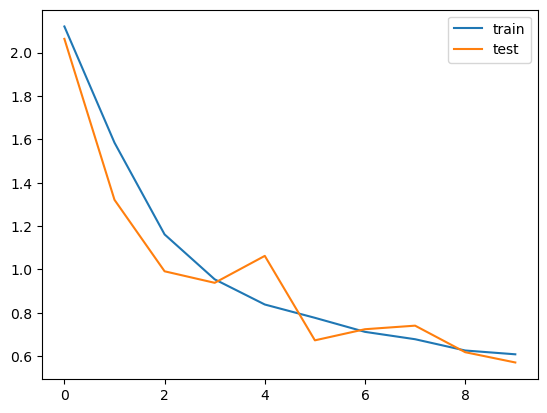

In [39]:
from matplotlib import pyplot
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='test')
pyplot.legend()
pyplot.show()

In [41]:
from tensorflow.keras.models import load_model

model = load_model('best_model.keras')

In [43]:
def predict_audio(audio):
    prob = model.predict(audio.reshape(1,8000,1))
    return prob

In [44]:
import random
index=random.randint(0,len(x_val)-1)
samples=x_val[index].ravel()
print("Audio:",classes[np.argmax(y_val[index])])
ipd.Audio(samples, rate=8000)

Audio: on


In [46]:
print("Text:", predict_audio(samples))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
Text: [[7.8531634e-04 1.4595588e-04 4.9266087e-06 4.7404078e-06 3.7242880e-03
  9.9336797e-01 1.8757317e-03 4.2682291e-06 8.6572792e-05 2.5786511e-07]]


In [47]:
pip install sounddevice

Note: you may need to restart the kernel to use updated packages.


In [48]:
pip install soundfile

Note: you may need to restart the kernel to use updated packages.


In [49]:
import sounddevice as sd
import soundfile as sf
samplerate = 16000
duration = 1 # seconds
filename = 'yes.wav'
print("start")
mydata = sd.rec(int(samplerate * duration), samplerate=samplerate,
channels=1, blocking=True)
print("end")
sd.wait()
sf.write(filename, mydata, samplerate)

start
end


In [50]:
ls yes.wav

 Volume in drive C has no label.
 Volume Serial Number is 0E59-C2D5

 Directory of C:\Users\Abu Bakar

26/03/2026  01:08 am            32,044 yes.wav
               1 File(s)         32,044 bytes
               0 Dir(s)  20,395,180,032 bytes free


In [51]:
samples, sample_rate = librosa.load('yes.wav', sr = 16000)

In [52]:
ipd.Audio(samples, rate=sample_rate)

In [54]:
import librosa
import IPython.display as ipd

samples, sample_rate = librosa.load('yes.wav', sr=16000)  # Load audio
samples = librosa.resample(y=samples, orig_sr=sample_rate, target_sr=8000)  # Resample
ipd.Audio(samples, rate=8000)  # Play audio

In [59]:
import librosa
import numpy as np

# Load and resample the audio
samples, sample_rate = librosa.load('yes.wav', sr=16000)
samples = librosa.resample(y=samples, orig_sr=sample_rate, target_sr=8000)

# Define your prediction function
def predict_audio(audio):
    # Reshape to match model input
    audio = audio.reshape(1, 8000, 1)
    prob = model.predict(audio)
    return prob

# Call the function
output = predict_audio(samples)
print("Prediction:", output)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
Prediction: [[0.08180666 0.09834837 0.09727786 0.0942551  0.10817433 0.0884669
  0.11208259 0.09992427 0.12243338 0.09723058]]
